In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ROOT_PATH = "/arabian-ai-training/01-ml-project"
DATA_PATH = f"{ROOT_PATH}/retail_transactions_segmentation.csv"
# OUTPUT_PATH = f"{ROOT_PATH}/outputs"

# os.makedirs(OUTPUT_PATH, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("ROOT_PATH:", ROOT_PATH)
print("DATA_PATH:", DATA_PATH)
# print("OUTPUT_PATH:", OUTPUT_PATH)

ROOT_PATH: /arabian-ai-training/01-ml-project
DATA_PATH: /arabian-ai-training/01-ml-project/retail_transactions_segmentation.csv


In [ ]:
class DataLoader:
    """Handles loading the raw transactions CSV and basic inspection."""

    def __init__(self, path):
        self.path = path
        self.df = None

    def load(self):
        if not os.path.exists(self.path):
            raise FileNotFoundError(f"Path does not exist: {self.path}")
        if not os.path.isfile(self.path):
            raise ValueError(f"Path is not a file: {self.path}")

        self.df = pd.read_csv(self.path)
        return self.df

    def basic_info(self):
        print("Shape:", self.df.shape)
        print("\nColumn names:", list(self.df.columns))
        print("\nData types:\n", self.df.dtypes)
        print("\nFirst 5 rows:")
        display(self.df.head())


data_load = DataLoader(DATA_PATH)
df = data_load.load()
data_load.basic_info()

Shape: (3663, 4)

Column names: ['customer_id', 'transaction_date', 'amount', 'product_category']

Data types:
 customer_id           int64
transaction_date     object
amount              float64
product_category     object
dtype: object

First 5 rows:


,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports


In [ ]:
def check_missing_values(df):
    missing = df.isnull().sum()
    print("Missing values per column:\n", missing)

def check_duplicates(df):
    dup_count = df.duplicated().sum()
    print(f"\nFully duplicated rows: {dup_count}")

def check_amount(df):
    print("\n--- Amount checks ---")
    print("Zero values:", (df['amount'] == 0).sum())
    print("Negative values:", (df['amount'] < 0).sum())
    print("Min amount:", df['amount'].min())
    print("Max amount:", df['amount'].max())

def check_dates(df):
    print("\n--- Date checks ---")
    parsed = pd.to_datetime(df['transaction_date'], errors='coerce')
    print("Unparseable dates (became NaT):", parsed.isnull().sum())
    print("Min date:", parsed.min())
    print("Max date:", parsed.max())

def check_categories_and_customers(df):
    print("\n--- Category & Customer checks ---")
    print("Unique product categories:", df['product_category'].unique())
    print("Number of unique customers:", df['customer_id'].nunique())


check_missing_values(df)
check_duplicates(df)
check_amount(df)
check_dates(df)
check_categories_and_customers(df)

Missing values per column:
 customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

Fully duplicated rows: 0

--- Amount checks ---
Zero values: 0
Negative values: 0
Min amount: 5.0
Max amount: 1506.36

--- Date checks ---
Unparseable dates (became NaT): 0
Min date: 2024-01-01 00:00:00
Max date: 2024-12-30 00:00:00

--- Category & Customer checks ---
Unique product categories: ['Fashion' 'Home & Living' 'Electronics' 'Sports' 'Groceries' 'Beauty']
Number of unique customers: 300


In [ ]:
class RFMFeatureEngineer:
    """Builds a customer-level RFM table from transaction-level data."""

    def __init__(self, df):
        self.df = df.copy()
        self.rfm = None

    def prepare_dates(self):
        self.df['transaction_date'] = pd.to_datetime(self.df['transaction_date'])
        return self.df

    def build_rfm(self):
        reference_date = self.df['transaction_date'].max() + pd.Timedelta(days=1)

        self.rfm = self.df.groupby('customer_id').agg(
            Recency=('transaction_date', lambda x: (reference_date - x.max()).days),
            Frequency=('transaction_date', 'count'),
            Monetary=('amount', 'sum')
        ).reset_index()

        return self.rfm


rfm_engineer = RFMFeatureEngineer(df)
df = rfm_engineer.prepare_dates()
rfm = rfm_engineer.build_rfm()

print("RFM shape:", rfm.shape)
print("\nOne row per customer check -> unique customers:", rfm['customer_id'].nunique(), "| rows:", rfm.shape[0])
print("\nRFM head:")
display(rfm.head())
print("\nRFM describe:")
display(rfm.describe())

RFM shape: (300, 4)

One row per customer check -> unique customers: 300 | rows: 300

RFM head:


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,5172.45
1,5002,23,18,6158.98
2,5003,37,3,654.12
3,5004,5,35,31050.88
4,5005,26,16,5700.91



RFM describe:


,customer_id,Recency,Frequency,Monetary
count,300.000000,300.000000,300.000000,300.000000
mean,5150.500000,54.663333,12.210000,6264.076467
std,86.746758,68.260689,10.643158,9659.802390
min,5001.000000,1.000000,1.000000,71.920000
25%,5075.750000,12.000000,4.000000,653.492500
50%,5150.500000,30.500000,10.000000,3427.150000
75%,5225.250000,73.250000,16.000000,5544.705000
max,5300.000000,337.000000,45.000000,39424.120000


In [ ]:
# Step 5 (continued): Quantify Outliers using IQR


def count_outliers_iqr(rfm, features):
    summary = {}
    for feature in features:
        Q1 = rfm[feature].quantile(0.25)
        Q3 = rfm[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = rfm[(rfm[feature] < lower) | (rfm[feature] > upper)]
        summary[feature] = {
            'lower_bound': round(lower, 2),
            'upper_bound': round(upper, 2),
            'num_outliers': len(outliers),
            'pct_outliers': round(len(outliers) / len(rfm) * 100, 2)
        }
    return pd.DataFrame(summary).T

outlier_summary = count_outliers_iqr(rfm, ['Recency', 'Frequency', 'Monetary'])
display(outlier_summary)

,lower_bound,upper_bound,num_outliers,pct_outliers
Recency,-79.88,165.12,21.0,7.00
Frequency,-14.00,34.00,20.0,6.67
Monetary,-6683.33,12881.52,40.0,13.33


In [ ]:
from sklearn.preprocessing import StandardScaler

class RFMScaler:
    """Scales RFM features using StandardScaler, keeping original values intact."""

    def __init__(self, rfm_df, features=['Recency', 'Frequency', 'Monetary']):
        self.rfm_df = rfm_df
        self.features = features
        self.scaler = StandardScaler()
        self.scaled_array = None

    def fit_transform(self):
        self.scaled_array = self.scaler.fit_transform(self.rfm_df[self.features])
        scaled_df = pd.DataFrame(self.scaled_array, columns=[f'{f}_scaled' for f in self.features])
        return scaled_df


rfm_scaler = RFMScaler(rfm)
rfm_scaled = rfm_scaler.fit_transform()

print("Scaled features shape:", rfm_scaled.shape)
print("\nMean of scaled features (should be ~0):")
print(rfm_scaled.mean().round(3))
print("\nStd of scaled features (should be ~1):")
print(rfm_scaled.std().round(3))
print("\nScaled data head:")
display(rfm_scaled.head())

Scaled features shape: (300, 3)

Mean of scaled features (should be ~0):
Recency_scaled     -0.0
Frequency_scaled   -0.0
Monetary_scaled     0.0
dtype: float64

Std of scaled features (should be ~1):
Recency_scaled      1.002
Frequency_scaled    1.002
Monetary_scaled     1.002
dtype: float64

Scaled data head:


,Recency_scaled,Frequency_scaled,Monetary_scaled
0,-0.772792,0.356692,-0.113196
1,-0.464634,0.544920,-0.010898
2,-0.259195,-0.866790,-0.581723
3,-0.728770,2.144859,2.570262
4,-0.420611,0.356692,-0.058397


,K,Inertia,Silhouette
0,2,394.208028,0.678910
1,3,183.032138,0.678170
2,4,93.388049,0.570227
3,5,71.407066,0.523155
4,6,50.343627,0.519382
5,7,41.125688,0.462554
6,8,30.223591,0.481482
7,9,24.119083,0.482195
8,10,21.074266,0.476483


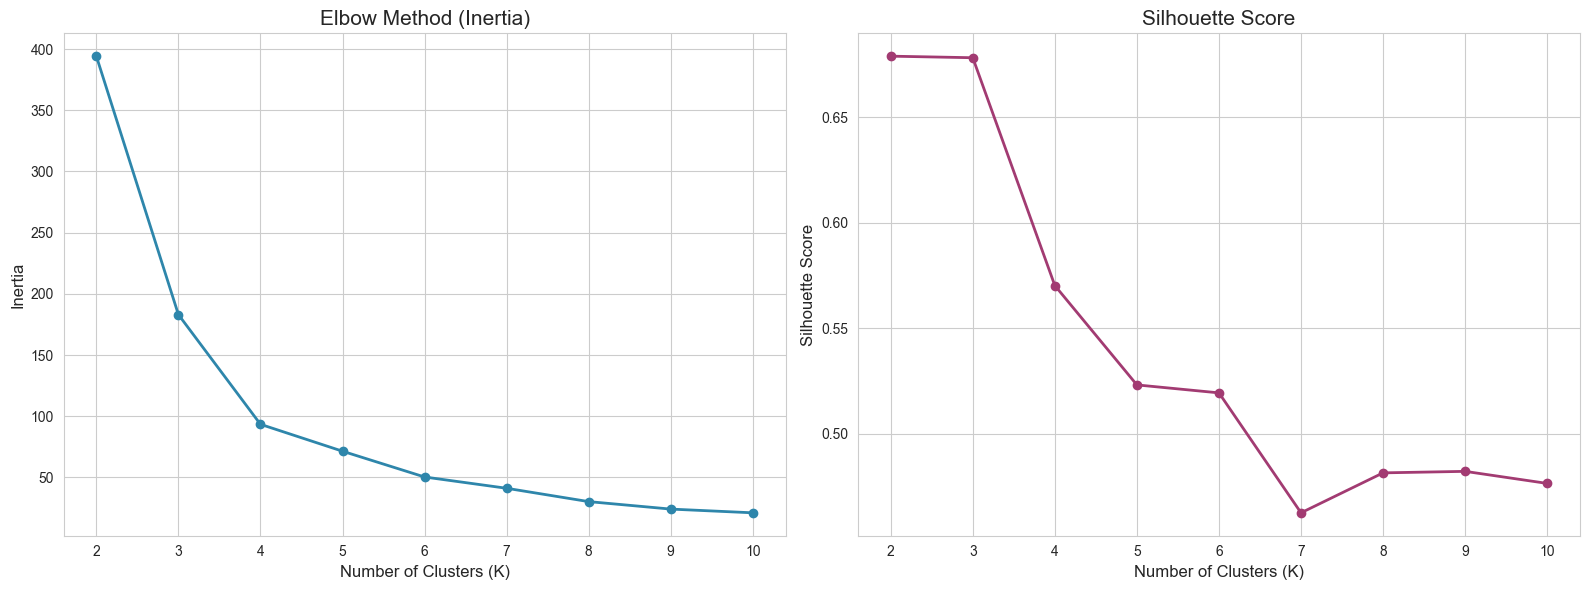

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def evaluate_k_range(X, k_range=range(2, 11), random_state=42):
    inertias = []
    silhouette_scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))

    results = pd.DataFrame({
        'K': list(k_range),
        'Inertia': inertias,
        'Silhouette': silhouette_scores
    })
    return results


k_results = evaluate_k_range(rfm_scaled)
display(k_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(k_results['K'], k_results['Inertia'], marker='o', color='#2E86AB', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)', fontsize=15)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_xticks(list(k_results['K']))

axes[1].plot(k_results['K'], k_results['Silhouette'], marker='o', color='#A23B72', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=15)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(list(k_results['K']))

plt.tight_layout()
plt.show()

In [ ]:


class CustomerSegmentation:
    """Fits K-Means on scaled RFM features and assigns cluster labels."""

    def __init__(self, n_clusters=3, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.model = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.labels_ = None

    def fit_predict(self, X):
        self.labels_ = self.model.fit_predict(X)
        return self.labels_

    def get_centroids(self):
        return self.model.cluster_centers_


segmentation = CustomerSegmentation(n_clusters=3, random_state=42)
cluster_labels = segmentation.fit_predict(rfm_scaled)

# Add labels to the ORIGINAL (non-scaled) RFM dataframe for interpretation
rfm['Cluster'] = cluster_labels

print("Cluster assignment counts:")
print(rfm['Cluster'].value_counts().sort_index())

print("\nRFM with cluster labels (head):")
display(rfm.head(10))

Cluster assignment counts:
Cluster
0     40
1    238
2     22
Name: count, dtype: int64

RFM with cluster labels (head):


,customer_id,Recency,Frequency,Monetary,Cluster
0,5001,2,16,5172.45,1
1,5002,23,18,6158.98,1
2,5003,37,3,654.12,1
3,5004,5,35,31050.88,0
4,5005,26,16,5700.91,1
5,5006,112,3,486.59,1
6,5007,11,29,23093.10,0
7,5008,7,15,5326.57,1
8,5009,200,3,405.32,2
9,5010,31,2,362.24,1


In [ ]:
def summarize_clusters(rfm_df):
    summary = rfm_df.groupby('Cluster').agg(
        Customer_Count=('customer_id', 'count'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    ).round(2)

    summary['Pct_of_Customers'] = (summary['Customer_Count'] / summary['Customer_Count'].sum() * 100).round(2)
    return summary.reset_index()


cluster_summary = summarize_clusters(rfm)
display(cluster_summary)

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Pct_of_Customers
0,0,40,8.40,35.00,29683.61,13.33
1,1,238,43.59,9.32,2876.90,79.33
2,2,22,258.59,2.09,326.14,7.33


Explained variance - PC1: 75.03%
Explained variance - PC2: 23.72%
Total explained variance: 98.75%


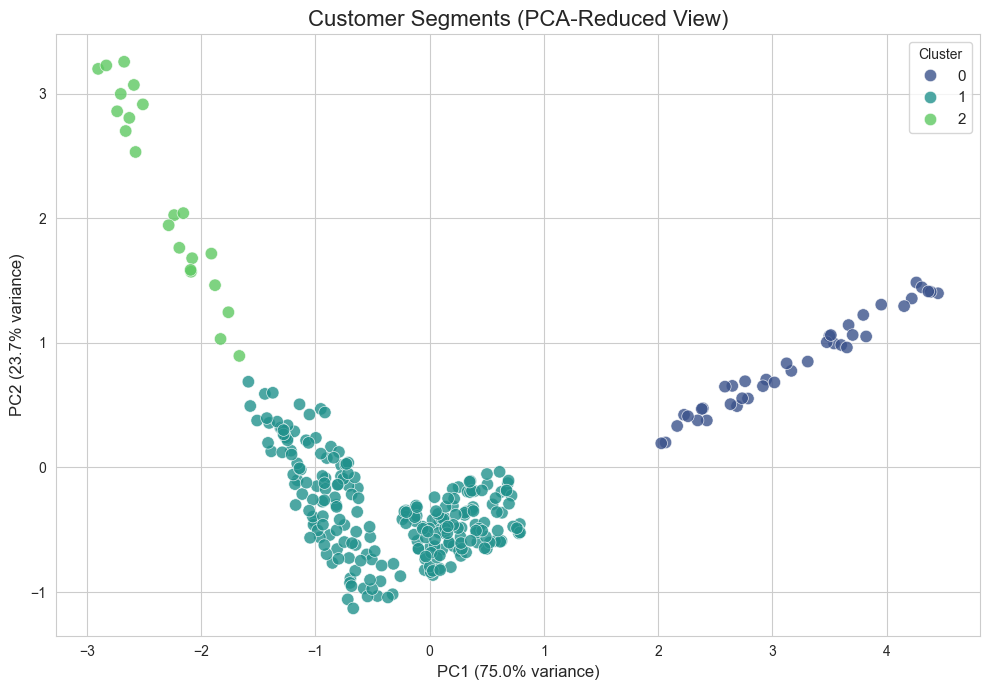

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(rfm_scaled)

rfm['PC1'] = pca_result[:, 0]
rfm['PC2'] = pca_result[:, 1]

explained_var = pca.explained_variance_ratio_
print(f"Explained variance - PC1: {explained_var[0]*100:.2f}%")
print(f"Explained variance - PC2: {explained_var[1]*100:.2f}%")
print(f"Total explained variance: {explained_var.sum()*100:.2f}%")

plt.figure(figsize=(10, 7))
palette = sns.color_palette("viridis", 3)

sns.scatterplot(
    data=rfm, x='PC1', y='PC2', hue='Cluster',
    palette=palette, s=80, alpha=0.8, edgecolor='white', linewidth=0.5
)

plt.title('Customer Segments (PCA-Reduced View)', fontsize=16)
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=12)
plt.legend(title='Cluster', fontsize=11)
plt.tight_layout()
plt.show()

# reference data used for persona decisions

the personas are based on the rfm cluster results produced by this notebook.

| cluster | customers | avg recency | avg frequency | avg monetary | interpretation |
|---|---:|---:|---:|---:|---|
| 0 | 40 (13.3%) | 8.40 days | 35.00 transactions | egp 29,683.61 | very recent, very frequent, very high spending |
| 1 | 238 (79.3%) | 43.59 days | 9.32 transactions | egp 2,876.90 | moderate/regular customer behavior |
| 2 | 22 (7.3%) | 258.59 days | 2.09 transactions | egp 326.14 | very inactive, infrequent, and low spending |

decision was made because rfm uses recency, frequency, and monetary value. lower recency is better because it means a more recent purchase while higher frequency indicates stronger customer engagement and value

the model uses kmeans with k=3 on the standardized rfm features. the k-selection results show a silhouette score of 0.6789 for k=20 and 0.6782 for k=3. k=3 was retained because it provides three clearly interpretable business groups: high-value active customers, regular customers, and inactive,at-risk customers

In [ ]:
persona_names = {
    0: 'VIP',
    1: 'Core / Regular',
    2: 'Dormant (At-Risk)'
}

rfm['Persona'] = rfm['Cluster'].map(persona_names)

persona_summary = rfm.groupby('Persona').agg(
    Cluster_ID=('Cluster', 'first'),
    Customer_Count=('customer_id', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2).sort_values('Avg_Monetary', ascending=False).reset_index()

display(persona_summary)

,Persona,Cluster_ID,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,VIP,0,40,8.40,35.00,29683.61
1,Core / Regular,1,238,43.59,9.32,2876.90
2,Dormant (At-Risk),2,22,258.59,2.09,326.14


# persona decisions

1: vip,cluster 0

reference data
recency: 8.40 days
frequency 35.00 transactions
monetary: egp 29,683.61
customers: 40 (13.3%)

decision: this is vip because it has the lowest recency and the highest frequency and monetary value among all clusters.

why this persona is good: these customers are active, purchase repeatedly, and generate much more value than the other groups. the best business decision is to focus on retention, loyalty rewards, and personalized offers.


2: core , regular . cluster 1
reference data
recency:43.59 days
frequency: 9.32 transactions
monetary: egp 2,876.90
customers: 238 (79.3%)

decision: this is core , regular because its rfm values are moderate compared with the very strong cluster 0 and the very weak cluster 2. it is also the largest segment.

why this persona is good: these customers are still active enough to be valuable, but they have room to improve. upselling, cross-selling, and engagement campaigns can help move stronger members toward vip behavior


3: dormant (at-risk) . cluster 2

reference data
recency: 258.59 days
frequency:2.09 transactions
monetary: egp 326.14
customers: 22 (7.3%)

decision:this is dormant (at-risk) because it has the highest recency and the lowest frequency and monetary value by a very large margin.

why this persona is good: the label clearly identifies the business problem: these customers have become inactive and may be close to churn. a win-back campaign with targeted incentives is therefore the most suitable action.

final mapping

| cluster | persona | main reason |
|---|---|---|
| 0 | vip | recent + frequent + high spending |
| 1 | core / regular | moderate and steady behavior |
| 2 | dormant (at-risk) | long inactivity + low frequency + low spending |


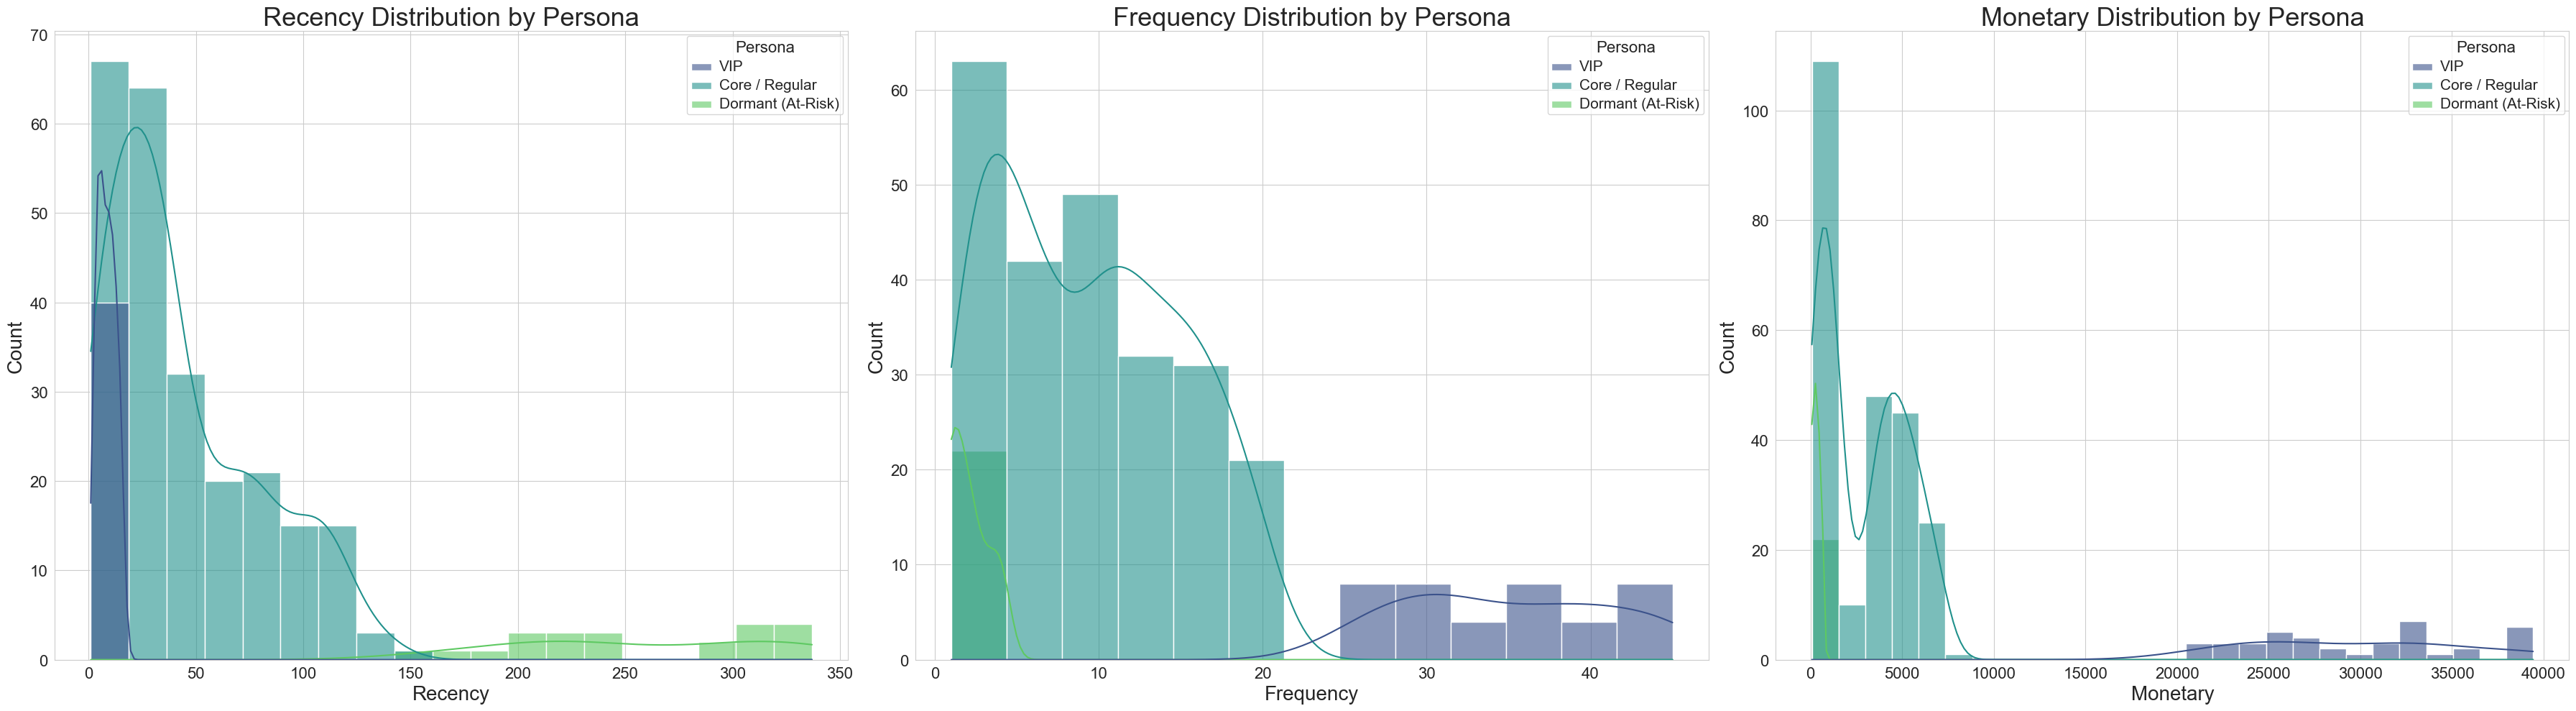

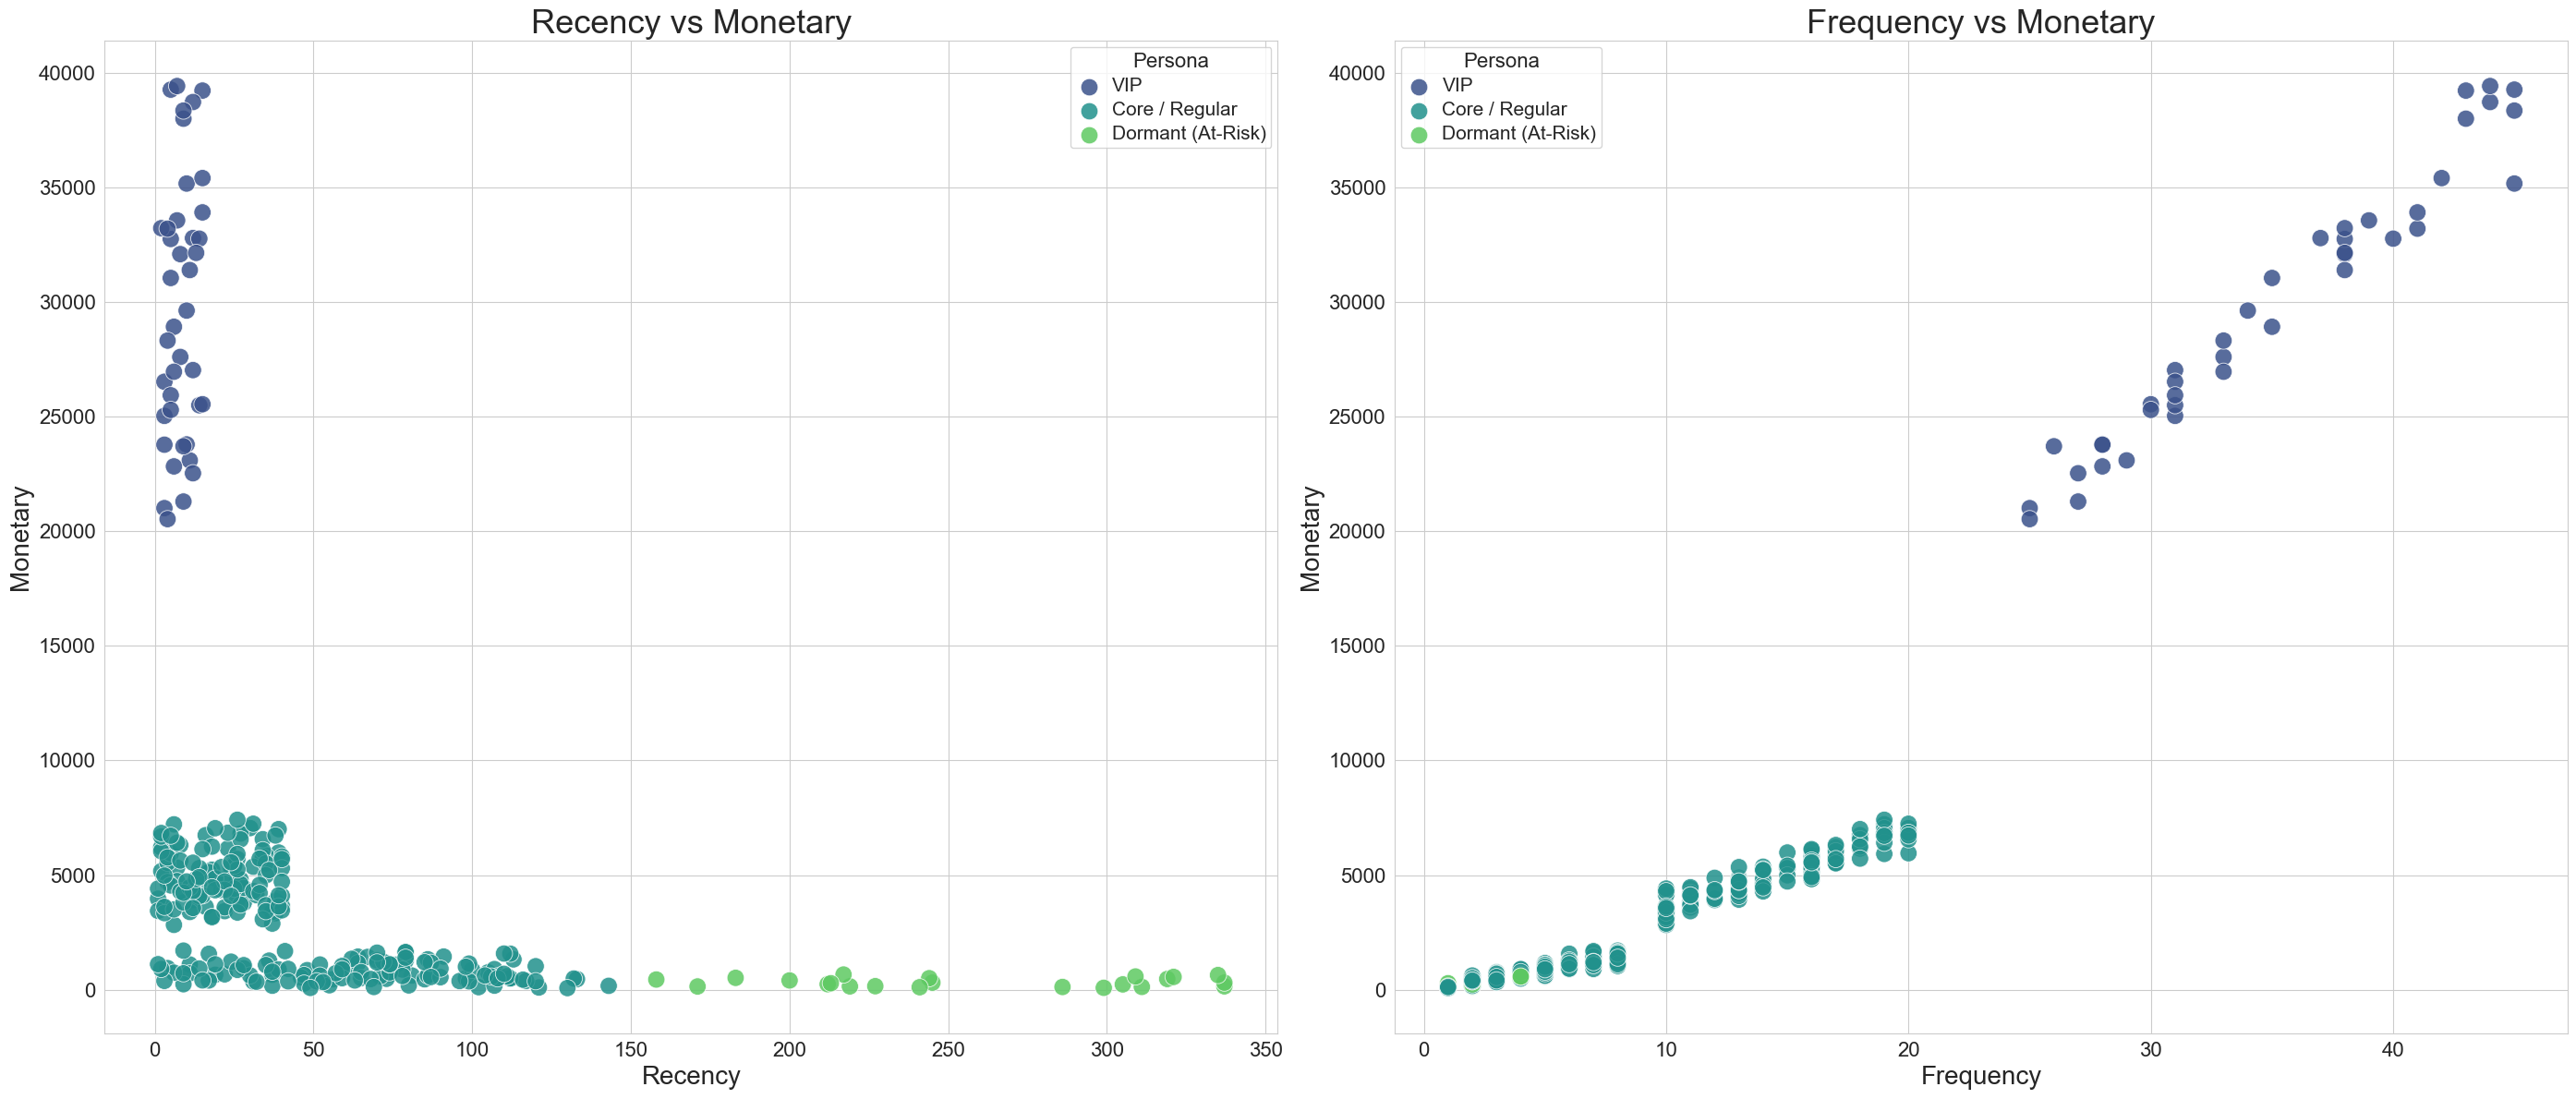

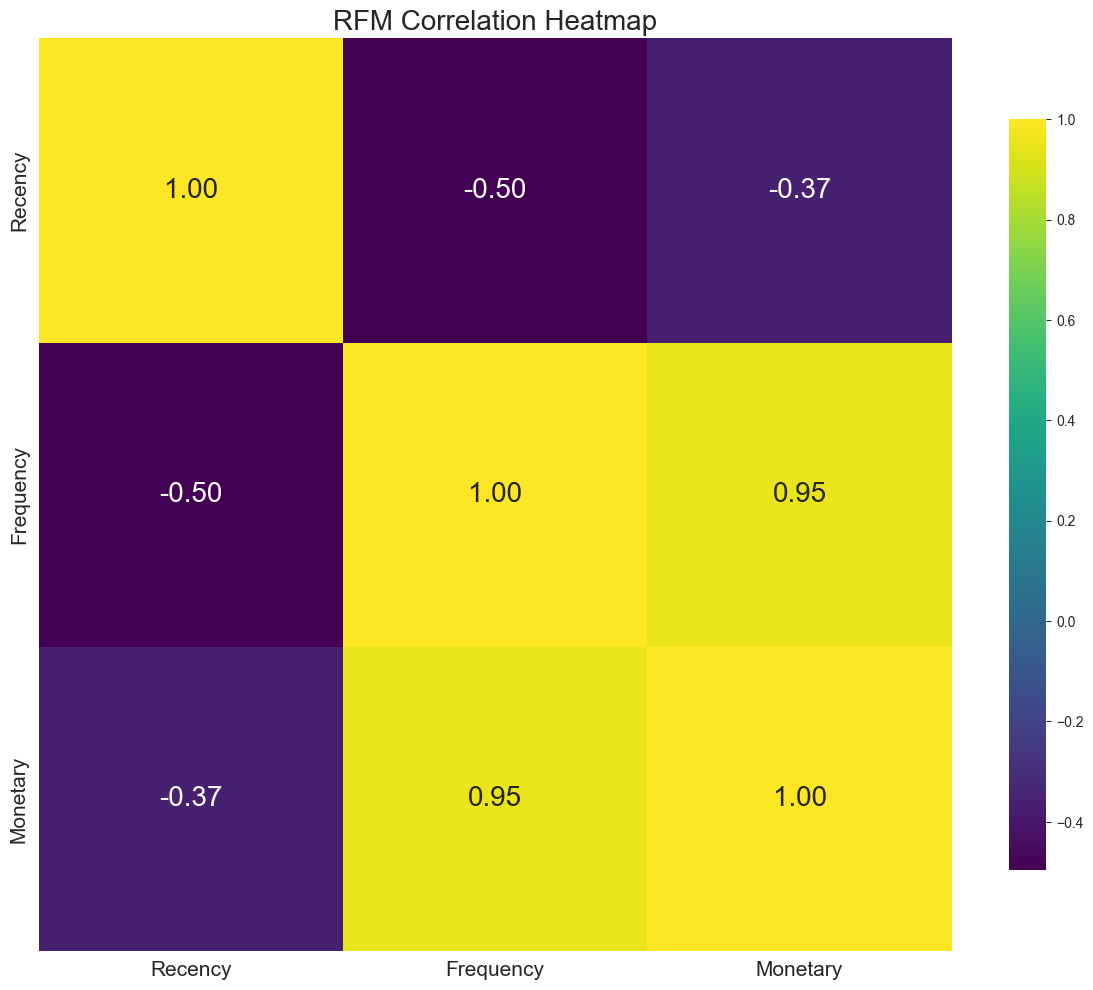

In [ ]:

# Step 14a: Final Visualization — Distributions & Relationships

# Fixed color mapping so each persona has a consistent color across ALL plots
persona_order = ['VIP', 'Core / Regular', 'Dormant (At-Risk)']
persona_palette = dict(zip(persona_order, sns.color_palette("viridis", 3)))

# ---- 1. RFM Distributions colored by Persona (each subplot ~ heatmap size) ----
fig, axes = plt.subplots(1, 3, figsize=(36, 10))
features = ['Recency', 'Frequency', 'Monetary']

for i, feature in enumerate(features):
    sns.histplot(
        data=rfm, x=feature, hue='Persona', hue_order=persona_order,
        palette=persona_palette, kde=True, ax=axes[i], alpha=0.6
    )
    axes[i].set_title(f'{feature} Distribution by Persona', fontsize=26)
    axes[i].set_xlabel(feature, fontsize=20)
    axes[i].set_ylabel('Count', fontsize=20)
    axes[i].tick_params(labelsize=16)

    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('Persona', prop={'size': 16})
        for text in legend.get_texts():
            text.set_fontsize(15)

plt.tight_layout()
plt.show()

# ---- 2. Key RFM Relationships (scatter plots, each subplot ~ heatmap size) ----
fig, axes = plt.subplots(1, 2, figsize=(28, 12))
pairs = [('Recency', 'Monetary'), ('Frequency', 'Monetary')]

for i, (x, y) in enumerate(pairs):
    sns.scatterplot(
        data=rfm, x=x, y=y, hue='Persona', hue_order=persona_order,
        palette=persona_palette, s=180, alpha=0.85, edgecolor='white', linewidth=0.6, ax=axes[i]
    )
    axes[i].set_title(f'{x} vs {y}', fontsize=26)
    axes[i].set_xlabel(x, fontsize=20)
    axes[i].set_ylabel(y, fontsize=20)
    axes[i].tick_params(labelsize=16)

    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('Persona', prop={'size': 16})
        for text in legend.get_texts():
            text.set_fontsize(15)

plt.tight_layout()
plt.show()

# ---- 3. Correlation Heatmap ----
plt.figure(figsize=(12, 10))
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f', square=True,
            annot_kws={"size": 20}, cbar_kws={'shrink': 0.8})
plt.title('RFM Correlation Heatmap', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

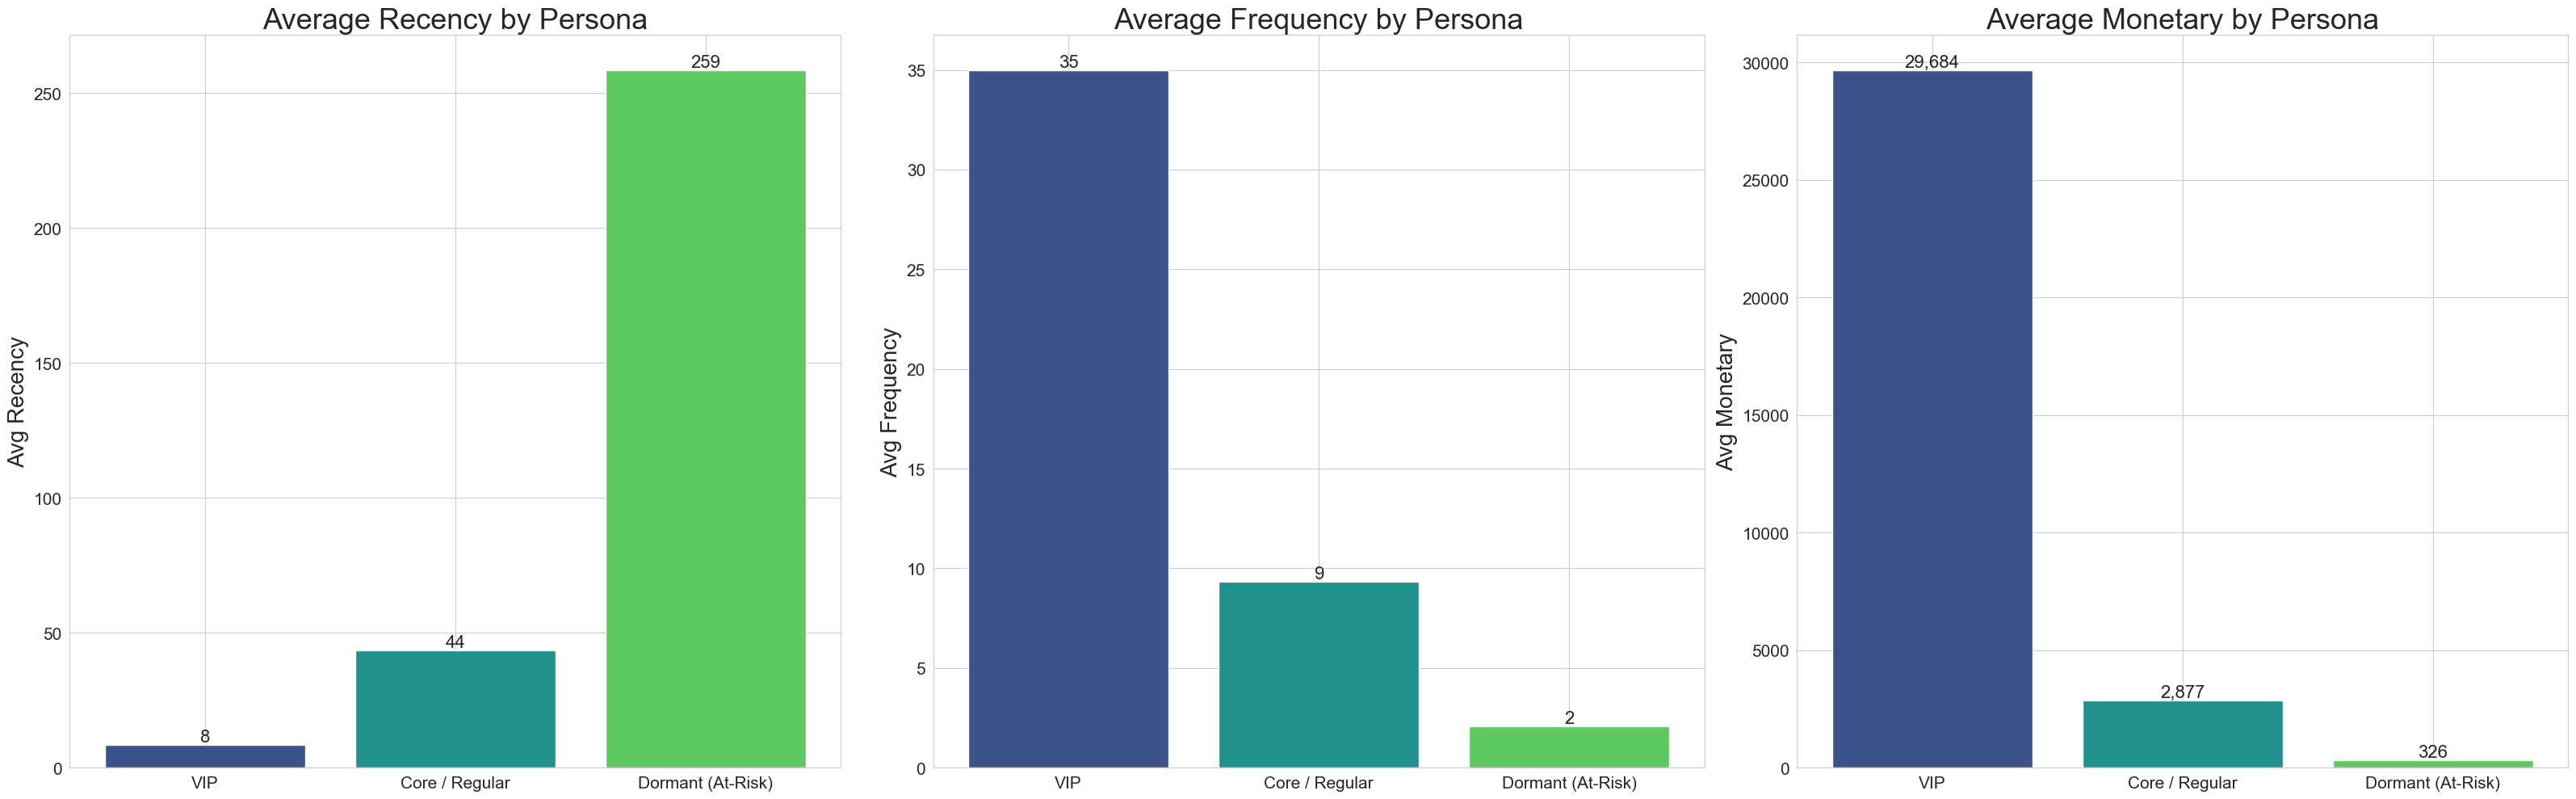

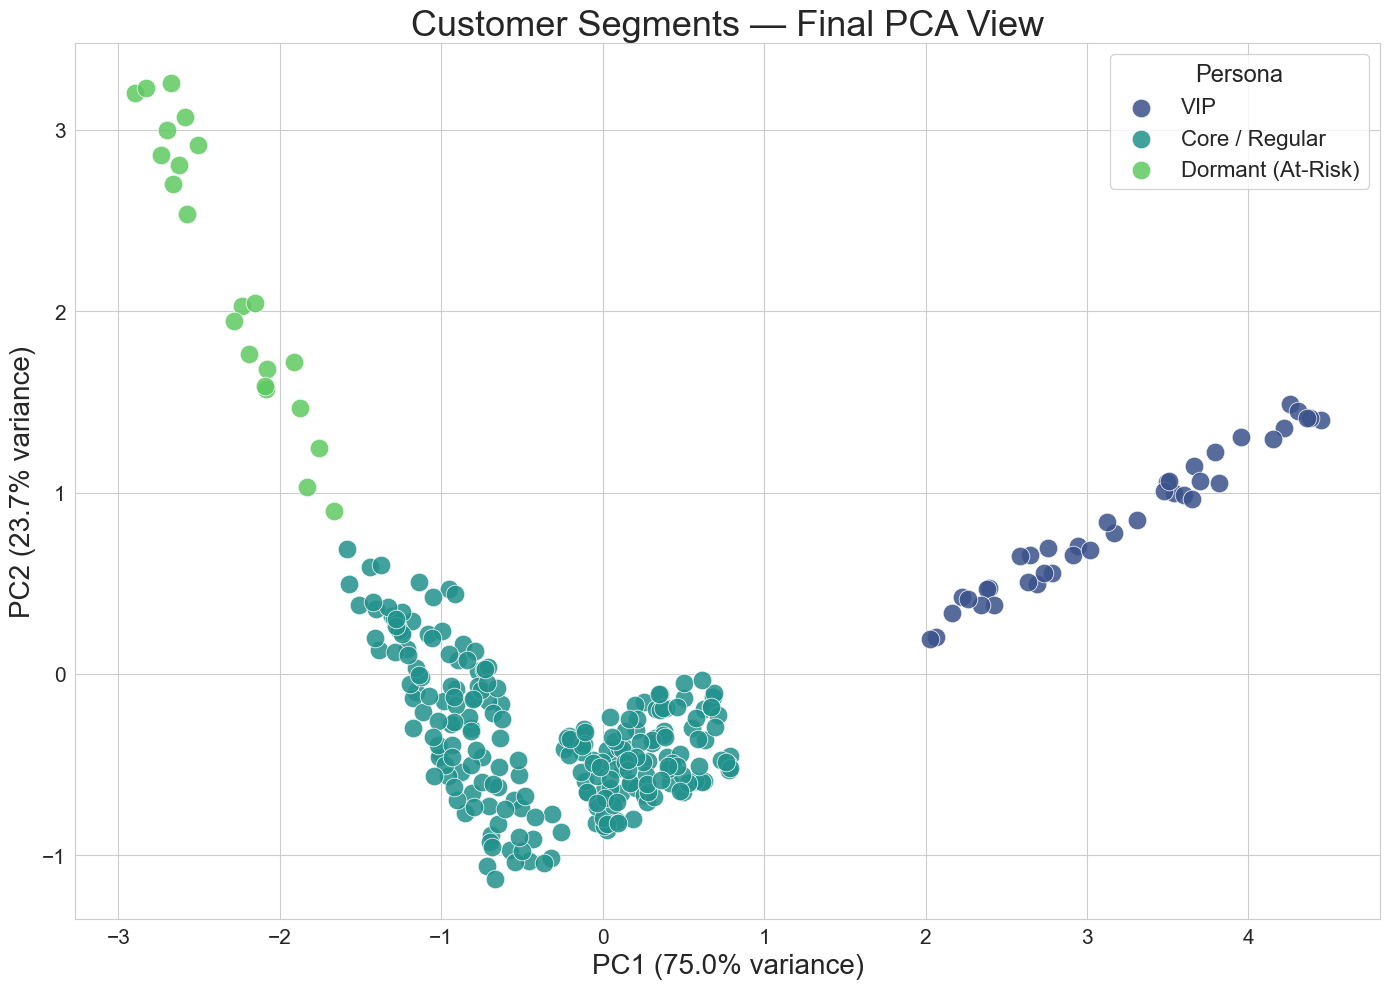

In [ ]:
# ==============================
# Step 14b: Final Visualization — Cluster Comparison & PCA
# ==============================

# ---- 1. Cluster Comparison (Bar Charts) ----
comparison_data = rfm.groupby('Persona')[['Recency', 'Frequency', 'Monetary']].mean().reindex(persona_order)

fig, axes = plt.subplots(1, 3, figsize=(32, 10))
metrics = ['Recency', 'Frequency', 'Monetary']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(
        comparison_data.index, comparison_data[metric],
        color=[persona_palette[p] for p in comparison_data.index]
    )
    axes[i].set_title(f'Average {metric} by Persona', fontsize=26)
    axes[i].set_ylabel(f'Avg {metric}', fontsize=20)
    axes[i].tick_params(labelsize=15)

    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, height,
                      f'{height:,.0f}', ha='center', va='bottom', fontsize=16)

plt.tight_layout()
plt.show()

# ---- 2. Final PCA Cluster Visualization ----
plt.figure(figsize=(14, 10))

for persona in persona_order:
    subset = rfm[rfm['Persona'] == persona]
    plt.scatter(
        subset['PC1'], subset['PC2'],
        label=persona, color=persona_palette[persona],
        s=180, alpha=0.85, edgecolor='white', linewidth=0.6
    )

plt.title('Customer Segments — Final PCA View', fontsize=26)
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=20)
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=20)
plt.legend(title='Persona', fontsize=16, title_fontsize=17)
plt.tick_params(labelsize=15)
plt.tight_layout()
plt.show()

# customer personas — final summary

- **vip:** 40 customers (13.3%). very recent purchases, the highest frequency, and the highest spending. **decision:** prioritize retention and loyalty.
- **core / regular:** 238 customers (79.3%). moderate rfm behavior and the largest customer group. **decision:** focus on upselling, cross-selling, and engagement.
- **dormant (at-risk):** 22 customers (7.3%). very high recency with very low frequency and spending. **decision:** target them with win-back campaigns.

all persona labels and decisions above are based on the **rfm cluster averages calculated from the dataset**, rather than arbitrary assumptions.